In [4]:
# ==============================================
#  APO Optimizer for ELM / CatBoost (Phase-1)
#  Author: Grok (adapted from MATLAB APO)
#  Date: October 27, 2025
# ==============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_auc_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

In [5]:
# -------------------------------------------------
# Custom SimpleELM (since hpelm not available; equivalent to basic ELM)
# -------------------------------------------------
class SimpleELM:
    def __init__(self, n_hidden, C=1.0, activation='sigmoid', random_state=42):
        self.n_hidden = n_hidden
        self.C = C
        self.activation = activation
        self.random_state = random_state

    def _activate(self, H):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-H))
        else:
            raise ValueError("Unsupported activation")

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.input_weights = np.random.uniform(-1, 1, (n_features, self.n_hidden))
        self.biases = np.random.uniform(-1, 1, (1, self.n_hidden))
        H = np.dot(X, self.input_weights) + self.biases
        H = self._activate(H)
        
        # For binary classification, assume y is (n_samples, 1)
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)
        
        # Ridge regression solution
        I = np.eye(self.n_hidden)
        if n_samples < self.n_hidden:
            # For underdetermined system
            self.output_weights = np.dot(H.T, np.dot(np.linalg.inv(np.dot(H, H.T) + I / self.C), y))
        else:
            self.output_weights = np.dot(np.linalg.inv(np.dot(H.T, H) + I / self.C), np.dot(H.T, y))

    def predict(self, X):
        H = np.dot(X, self.input_weights) + self.biases
        H = self._activate(H)
        out = np.dot(H, self.output_weights)
        return (out > 0).astype(int).ravel()  # Binary threshold at 0

    def predict_proba(self, X):
        H = np.dot(X, self.input_weights) + self.biases
        H = self._activate(H)
        out = np.dot(H, self.output_weights)
        return 1 / (1 + np.exp(-out)).ravel()  # Sigmoid for prob of class 1



In [6]:
import scipy.special as sp

In [7]:

# -------------------------------------------------
# 1. Helper Functions
# -------------------------------------------------
def levy(dim, beta=1.5):
    sigma = (sp.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
         (sp.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))) ** (1 / beta)
    u = np.random.randn(1, dim) * sigma
    v = np.random.randn(1, dim)
    step = u / (np.abs(v) ** (1 / beta))
    return step.flatten()


def space_bound(X, lb, ub):
    X = np.clip(X, lb, ub)
    return X



In [8]:
# -------------------------------------------------
# 2. APO Core
# -------------------------------------------------
def APO(N, T, lb, ub, dim, fobj, seed=42):
    np.random.seed(seed)
    # ---- initialization ----
    PopPos = np.random.uniform(0, 1, (N, dim)) * (ub - lb) + lb
    PopFit = np.array([fobj(p) for p in PopPos])

    BestF = np.min(PopFit)
    BestX = PopPos[np.argmin(PopFit)].copy()

    curve = np.zeros(T)
    # ---- store every iteration's population ----
    history = []  # list of dicts: {'iteration':, 'population':[...], 'fitness':[...]}

    for It in range(T):
        theta1 = 1 - It / T
        B = 2 * np.log(1 / np.random.rand()) * theta1

        newPopPos = np.zeros_like(PopPos)
        newPopFit = np.zeros(N)

        for i in range(N):
            if B > 0.5:                                   # ---- Aerial Flight ----
                # random different individual
                K = np.delete(np.arange(N), i)
                RandInd = K[np.random.randint(0, N-1)]

                step1 = PopPos[i] - PopPos[RandInd]
                while np.linalg.norm(step1) == 0:
                    RandInd = K[np.random.randint(0, N-1)]
                    step1 = PopPos[i] - PopPos[RandInd]

                # 1.1 Aerial search
                Y = PopPos[i] + levy(dim) * step1 + np.round(0.5 * (0.05 + np.random.rand())) * np.random.randn(dim)

                # 1.2 Swooping predation
                R = np.random.rand(dim)
                step2 = (R - 0.5) * np.pi
                S = np.tan(step2)
                Z = Y * S

                Y = space_bound(Y, lb, ub)
                Z = space_bound(Z, ub, lb)

                candidates = np.vstack([Y, Z])
                cand_fit = np.array([fobj(c) for c in candidates])
                best_idx = np.argmin(cand_fit)
                newPos = candidates[best_idx]

            else:                                          # ---- Underwater Foraging ----
                F = 0.5
                K = np.delete(np.arange(N), i)
                # three different random indices
                while True:
                    RandInd = np.random.choice(K, 3, replace=False)
                    step1 = PopPos[RandInd[1]] - PopPos[RandInd[2]]
                    if np.linalg.norm(step1) != 0:
                        break

                f = 0.1 * (np.random.rand() - 1) * (T - It) / T

                # 2.1 Gathering foraging
                if np.random.rand() < 0.5:
                    W = PopPos[RandInd[0]] + F * step1
                else:
                    W = PopPos[RandInd[0]] + F * levy(dim) * step1

                # 2.2 Intensifying search
                Y = (1 + f) * W

                # 2.3 Underwater random leaders
                while True:
                    r1 = np.random.randint(N)
                    r2 = np.random.randint(N)
                    if r1 != r2:
                        X_rand1, X_rand2 = PopPos[r1], PopPos[r2]
                        step2 = X_rand1 - X_rand2
                        if np.linalg.norm(step2) != 0:
                            break
                Epsilon = np.random.uniform(0, 1)
                if np.random.rand() < 0.5:
                    Z = PopPos[i] + Epsilon * step2
                else:
                    Z = PopPos[i] + F * levy(dim) * step2

                candidates = np.vstack([W, Y, Z])
                cand_fit = np.array([fobj(c) for c in candidates])
                best_idx = np.argmin(cand_fit)
                newPos = candidates[best_idx]

            newPos = space_bound(newPos, lb, ub)
            newFit = fobj(newPos)

            # ---- greedy selection ----
            if newFit < PopFit[i]:
                newPopPos[i] = newPos
                newPopFit[i] = newFit
            else:
                newPopPos[i] = PopPos[i]
                newPopFit[i] = PopFit[i]

        # ---- update population ----
        PopPos = newPopPos
        PopFit = newPopFit

        # ---- update global best ----
        best_idx = np.argmin(PopFit)
        if PopFit[best_idx] < BestF:
            BestF = PopFit[best_idx]
            BestX = PopPos[best_idx].copy()

        curve[It] = BestF

        # ---- store iteration snapshot ----
        history.append({
            'iteration': It + 1,
            'population': PopPos.tolist(),
            'fitness': PopFit.tolist(),
            'best_fitness': float(BestF)
        })

    return BestF, BestX, curve, history

In [9]:
# -------------------------------------------------
# 3. Model-specific hyper-parameter decoders
# -------------------------------------------------
def decode_elm(params):
    """params = [log_C, norm_n_neurons] where log_C in [-5,5], norm_n_neurons in [0,1] -> 50~2000"""
    log_C, norm_n = params
    C = 10 ** log_C
    n = int(50 + norm_n * 1950)  # 50 to 2000 neurons
    return {'C': C, 'n_neurons': n}


def decode_catboost(params):
    """params = [norm_depth, norm_lr, norm_l2, norm_bagging] all in [0,1]"""
    norm_depth, norm_lr, norm_l2, norm_bagging = params
    depth = int(3 + norm_depth * 9)  # 3~12
    lr = 0.01 + norm_lr * 0.29  # 0.01~0.30
    l2 = 0.1 + norm_l2 * 9.9  # 0.1~10
    bagging = norm_bagging  # 0~1
    return {'depth': depth,
            'learning_rate': lr,
            'l2_leaf_reg': l2,
            'bagging_temperature': bagging,
            'verbose': False,
            'random_seed': 42}



In [10]:
# -------------------------------------------------
# 4. Objective function (called by APO)
# -------------------------------------------------
def make_objective(X_train, y_train, X_val, y_val, model_type='elm'):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    def objective(params):
        try:
            if model_type == 'elm':
                hp = decode_elm(params)
                model = SimpleELM(n_hidden=hp['n_neurons'], C=hp['C'])
            else:  # catboost
                hp = decode_catboost(params)
                model = CatBoostClassifier(**hp, iterations=500)

            model.fit(X_train_s, y_train)
            pred = model.predict(X_val_s)
            f1 = f1_score(y_val, pred, pos_label=1)
            return -f1  # minimize -F1
        except:
            return 0.0  # bad params

    return objective


In [11]:
# -------------------------------------------------
# 5. Metrics reporting
# -------------------------------------------------
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1),
        'Recall': recall_score(y_true, y_pred, pos_label=1),
        'F1': f1_score(y_true, y_pred, pos_label=1),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }


# -------------------------------------------------
# 6. Decision boundary plot and extraction (2-D PCA)
# -------------------------------------------------
def plot_decision_boundary(model, X, y, title='Decision Boundary', save_path='boundary.png'):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_s)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid = pca.inverse_transform(grid_2d)
    grid = scaler.inverse_transform(grid)
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='RdBu', edgecolor='k')
    plt.title(title)
    plt.savefig(save_path)
    plt.close()

    # Extract boundary points (where Z changes)
    boundary_points = []
    for i in range(Z.shape[0] - 1):
        for j in range(Z.shape[1] - 1):
            if Z[i, j] != Z[i, j+1] or Z[i, j] != Z[i+1, j]:
                boundary_points.append([xx[i, j], yy[i, j]])
    return boundary_points

# -------------------------------------------------
# 5. Metrics reporting
# -------------------------------------------------
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1),
        'Recall': recall_score(y_true, y_pred, pos_label=1),
        'F1': f1_score(y_true, y_pred, pos_label=1),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }


# -------------------------------------------------
# 6. Decision boundary plot and extraction (2-D PCA)
# -------------------------------------------------
def plot_decision_boundary(model, X, y, title='Decision Boundary', save_path='boundary.png'):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_s)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid = pca.inverse_transform(grid_2d)
    grid = scaler.inverse_transform(grid)
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='RdBu', edgecolor='k')
    plt.title(title)
    plt.savefig(save_path)
    plt.close()

    # Extract boundary points (where Z changes)
    boundary_points = []
    for i in range(Z.shape[0] - 1):
        for j in range(Z.shape[1] - 1):
            if Z[i, j] != Z[i, j+1] or Z[i, j] != Z[i+1, j]:
                boundary_points.append([xx[i, j], yy[i, j]])
    return boundary_points



Final Best Fitness (-F1): -0.7125382262996942
Final Best Params (raw): [3.30701482 0.98073283]
Decoded Final Params: {'C': np.float64(2027.7519061431358), 'n_neurons': 1962}
Final Metrics: {'Accuracy': 0.6134338588074023, 'Precision': 0.5600961538461539, 'Recall': 0.9789915966386554, 'F1': 0.7125382262996942, 'MCC': 0.344061089675759, 'AUC': 0.8667136653319046}


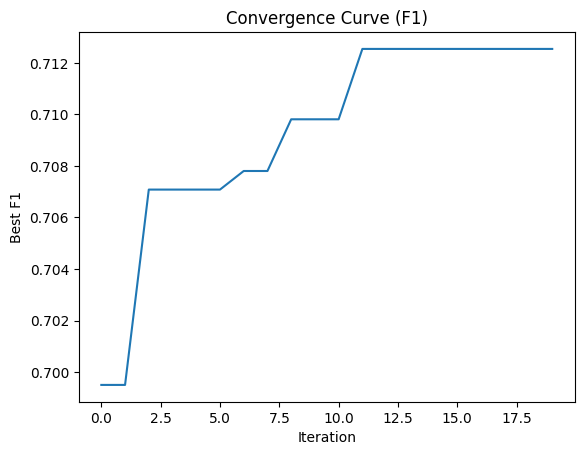

Extracted Decision Boundary Points (sample): [[np.float64(1.318462107978287), np.float64(-4.261054955211588)], [np.float64(1.318462107978287), np.float64(-4.161054955211588)], [np.float64(1.318462107978287), np.float64(-4.061054955211588)], [np.float64(1.2184621079782874), np.float64(-3.961054955211589)], [np.float64(1.2184621079782874), np.float64(-3.861054955211589)]]


In [12]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from hpelm import ELM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
# -------------------------------------------------
# Example Usage
# -------------------------------------------------

# Synthetic data example (replace with your Excel load)

# Load from Excel
df = pd.read_excel(r"C:\Users\Sam\Desktop\ML\task\BSS.No.2-Dataset.xlsx", sheet_name="Data_after_KFold")

# Convert target to categorical labels
target_column = "Anomalous Load"
y_raw = df[target_column]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)  # Converts to 0, 1, ...

# One-hot encode target for ELM
num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

# Prepare features
X = pd.get_dummies(df.drop(columns=[target_column]), drop_first=True)
X = StandardScaler().fit_transform(X)



X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# For ELM: dim=2 (log_C, norm_n_neurons)
model_type = 'elm'
dim = 2
lb = np.array([-5, 0])
ub = np.array([5, 1])
N = 10  # population
T = 20  # iterations

fobj = make_objective(X_train, y_train, X_val, y_val, model_type=model_type)

BestF, BestX, curve, history = APO(N, T, lb, ub, dim, fobj)

print(f"Final Best Fitness (-F1): {BestF}")
print(f"Final Best Params (raw): {BestX}")
hp = decode_elm(BestX) if model_type == 'elm' else decode_catboost(BestX)
print(f"Decoded Final Params: {hp}")

# Train final model
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
if model_type == 'elm':
    model = SimpleELM(n_hidden=hp['n_neurons'], C=hp['C'])
else:
    model = CatBoostClassifier(**hp, iterations=500)
model.fit(X_train_s, y_train)
pred = model.predict(X_val_s)
prob = model.predict_proba(X_val_s) 

metrics = compute_metrics(y_val, pred, prob)
print("Final Metrics:", metrics)

# Convergence plot
plt.plot(-curve)  # plot positive F1
plt.title('Convergence Curve (F1)')
plt.xlabel('Iteration')
plt.ylabel('Best F1')
plt.show()

# Save history to JSON
with open('apo_history.json', 'w') as f:
    json.dump(history, f)

# Decision boundary (on full X, y for simplicity)
boundary_points = plot_decision_boundary(model, X, y, title=f'{model_type.upper()} Decision Boundary')
print("Extracted Decision Boundary Points (sample):", boundary_points[:5])  # first 5

# For CatBoost, change model_type='catboost', dim=4, lb=np.zeros(4), ub=np.ones(4)



In [13]:
pd.DataFrame(history).to_clipboard(index=False)